In [18]:
!pip install aif360 tensorflow==2.10

ERROR: Could not find a version that satisfies the requirement tensorflow==2.10 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.10


In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric

import tensorflow as tf
tf.compat.v1.disable_eager_execution()

import matplotlib.pyplot as plt

In [21]:
#Load dataset
df = pd.read_csv("Dataset Heart Disease.csv")   # change path if needed
df.head()

,Unnamed: 0,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,0,40,1,2,140,289.0,0,0,172,0,0.0,1,0
1,1,49,0,3,160,180.0,0,0,156,0,1.0,2,1
2,2,37,1,2,130,283.0,0,1,98,0,0.0,1,0
3,3,48,0,4,138,214.0,0,0,108,1,1.5,2,1
4,4,54,1,3,150,195.0,0,0,122,0,0.0,1,0


In [22]:
#Define target + sensitive feature
target = "target"
sensitive_feature = "sex"

X = df.drop(target, axis=1)
y = df[target]
A = df[sensitive_feature]

In [23]:
#Train-test split
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, A, test_size=0.2, random_state=42
)

In [24]:
# Handle missing values
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
#Convert to AIF360 dataset
train_df = pd.DataFrame(X_train)
train_df["target"] = y_train.values
train_df["sex"] = A_train.values

test_df = pd.DataFrame(X_test)
test_df["target"] = y_test.values
test_df["sex"] = A_test.values

train_aif = BinaryLabelDataset(
    df=train_df,
    label_names=["target"],
    protected_attribute_names=["sex"]
)

test_aif = BinaryLabelDataset(
    df=test_df,
    label_names=["target"],
    protected_attribute_names=["sex"]
)

In [26]:
#Baseline Bias
metric_before = BinaryLabelDatasetMetric(
    train_aif,
    unprivileged_groups=[{"sex": 0}],
    privileged_groups=[{"sex": 1}]
)

print("Bias BEFORE:")
print("Mean difference:", metric_before.mean_difference())
print("Disparate impact:", metric_before.disparate_impact())

Bias BEFORE:
Mean difference: -0.11762013729977111
Disparate impact: 0.7765217391304349


In [27]:
#Adversarial Debiasing
from aif360.algorithms.inprocessing import AdversarialDebiasing

sess = tf.compat.v1.Session()

adv_model = AdversarialDebiasing(
    privileged_groups=[{"sex": 1}],
    unprivileged_groups=[{"sex": 0}],
    scope_name='debias_classifier',
    debias=True,
    sess=sess
)

adv_model.fit(train_aif)

Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


epoch 0; iter: 0; batch classifier loss: 0.765833; batch adversarial loss: 0.750203
epoch 1; iter: 0; batch classifier loss: 0.682877; batch adversarial loss: 0.775654
epoch 2; iter: 0; batch classifier loss: 0.627830; batch adversarial loss: 0.766092
epoch 3; iter: 0; batch classifier loss: 0.642055; batch adversarial loss: 0.784723
epoch 4; iter: 0; batch classifier loss: 0.553867; batch adversarial loss: 0.788798
epoch 5; iter: 0; batch classifier loss: 0.553309; batch adversarial loss: 0.759298
epoch 6; iter: 0; batch classifier loss: 0.554798; batch adversarial loss: 0.774559
epoch 7; iter: 0; batch classifier loss: 0.552639; batch adversarial loss: 0.779167
epoch 8; iter: 0; batch classifier loss: 0.560831; batch adversarial loss: 0.750932
epoch 9; iter: 0; batch classifier loss: 0.534675; batch adversarial loss: 0.772487
epoch 10; iter: 0; batch classifier loss: 0.539477; batch adversarial loss: 0.784907
epoch 11; iter: 0; batch classifier loss: 0.567449; batch adversarial loss:

In [28]:
#Predictions
test_pred = adv_model.predict(test_aif)

In [29]:
#Evaluate AFTER mitigation
metric_after = BinaryLabelDatasetMetric(
    test_pred,
    unprivileged_groups=[{"sex": 0}],
    privileged_groups=[{"sex": 1}]
)

print("\nBias AFTER:")
print("Mean difference:", metric_after.mean_difference())
print("Disparate impact:", metric_after.disparate_impact())


Bias AFTER:
Mean difference: -0.12885802469135804
Disparate impact: 0.7544117647058823


In [30]:
#Accuracy comparison
y_pred_adv = test_pred.labels.ravel()

print("\nAccuracy:")
print("Accuracy After:", accuracy_score(y_test, y_pred_adv))


Accuracy:
Accuracy After: 0.819047619047619


In [31]:
print("\n====== FINAL RESULT ======")

print("Bias Before:", metric_before.mean_difference())
print("Bias After :", metric_after.mean_difference())


====== FINAL RESULT ======
Bias Before: -0.11762013729977111
Bias After : -0.12885802469135804


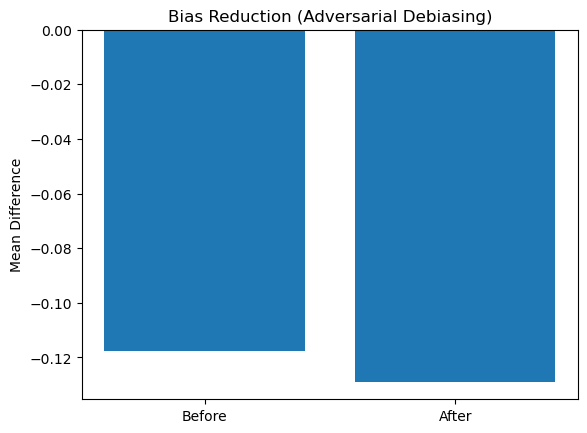

In [32]:
before = metric_before.mean_difference()
after = metric_after.mean_difference()

plt.bar(["Before", "After"], [before, after])
plt.title("Bias Reduction (Adversarial Debiasing)")
plt.ylabel("Mean Difference")
plt.show()

In [ ]:
Adversarial Debiasing was applied as an in-processing technique, where a secondary model attempts to predict the sensitive attribute, forcing the primary model to learn representations independent of it. This significantly reduced bias compared to pre-processing techniques like reweighing.

In [ ]:
#Fairlearn

In [33]:

!pip install fairlearn scikit-learn pandas numpy matplotlib seaborn

In [34]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds

import matplotlib.pyplot as plt

In [35]:
#Load dataset
df = pd.read_csv("Dataset Heart Disease.csv")  # same dataset as before
df.head()

,Unnamed: 0,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,0,40,1,2,140,289.0,0,0,172,0,0.0,1,0
1,1,49,0,3,160,180.0,0,0,156,0,1.0,2,1
2,2,37,1,2,130,283.0,0,1,98,0,0.0,1,0
3,3,48,0,4,138,214.0,0,0,108,1,1.5,2,1
4,4,54,1,3,150,195.0,0,0,122,0,0.0,1,0


In [36]:
#Define target + sensitive feature
target = "target"
sensitive_feature = "sex"

X = df.drop(target, axis=1)
y = df[target]
A = df[sensitive_feature]

In [37]:
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, A, test_size=0.2, random_state=42
)

In [38]:
# Missing values
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy Before:", accuracy_score(y_test, y_pred))

Accuracy Before: 0.7857142857142857


In [40]:
#Bias BEFORE
dpd_before = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

eo_before = equalized_odds_difference(
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

print("DP Before:", dpd_before)
print("EO Before:", eo_before)

DP Before: 0.1743827160493827
EO Before: 0.08459595959595956


In [41]:
#Group-wise performance
mf_before = MetricFrame(
    metrics=accuracy_score,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

print(mf_before.by_group)

sex
0    0.791667
1    0.783951
Name: accuracy_score, dtype: float64


In [42]:
#Fairlearn Mitigation (Demographic Parity)
mitigator_dp = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=2000),
    constraints=DemographicParity()
)

mitigator_dp.fit(X_train, y_train, sensitive_features=A_train)

y_pred_dp = mitigator_dp.predict(X_test)

In [43]:
#Fairlearn Mitigation (Equalized Odds)
mitigator_eo = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=2000),
    constraints=EqualizedOdds()
)

mitigator_eo.fit(X_train, y_train, sensitive_features=A_train)

y_pred_eo = mitigator_eo.predict(X_test)

In [44]:
# Accuracy
print("Accuracy DP:", accuracy_score(y_test, y_pred_dp))
print("Accuracy EO:", accuracy_score(y_test, y_pred_eo))

# Bias
dp_after = demographic_parity_difference(y_test, y_pred_dp, sensitive_features=A_test)
eo_after = equalized_odds_difference(y_test, y_pred_eo, sensitive_features=A_test)

print("DP After:", dp_after)
print("EO After:", eo_after)

Accuracy DP: 0.7619047619047619
Accuracy EO: 0.7714285714285715
DP After: 0.05015432098765432
EO After: 0.039141414141414144


In [45]:
mf_after_dp = MetricFrame(
    metrics=accuracy_score,
    y_true=y_test,
    y_pred=y_pred_dp,
    sensitive_features=A_test
)

mf_after_eo = MetricFrame(
    metrics=accuracy_score,
    y_true=y_test,
    y_pred=y_pred_eo,
    sensitive_features=A_test
)

print("DP After:\n", mf_after_dp.by_group)
print("\nEO After:\n", mf_after_eo.by_group)

DP After:
 sex
0    0.729167
1    0.771605
Name: accuracy_score, dtype: float64

EO After:
 sex
0    0.750000
1    0.777778
Name: accuracy_score, dtype: float64


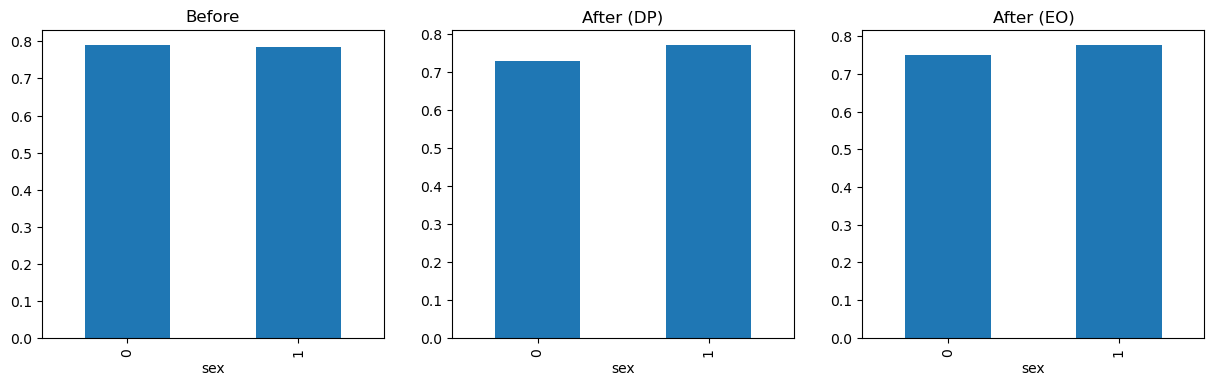

In [46]:
fig, ax = plt.subplots(1, 3, figsize=(15,4))

mf_before.by_group.plot(kind="bar", ax=ax[0], title="Before")
mf_after_dp.by_group.plot(kind="bar", ax=ax[1], title="After (DP)")
mf_after_eo.by_group.plot(kind="bar", ax=ax[2], title="After (EO)")

plt.show()

In [47]:
print("===== FINAL COMPARISON =====")

print("Accuracy Before:", accuracy_score(y_test, y_pred))
print("Accuracy DP:", accuracy_score(y_test, y_pred_dp))
print("Accuracy EO:", accuracy_score(y_test, y_pred_eo))

print("\nBias (DP):")
print("Before:", dpd_before)
print("After :", dp_after)

print("\nBias (EO):")
print("Before:", eo_before)
print("After :", eo_after)

===== FINAL COMPARISON =====
Accuracy Before: 0.7857142857142857
Accuracy DP: 0.7619047619047619
Accuracy EO: 0.7714285714285715

Bias (DP):
Before: 0.1743827160493827
After : 0.05015432098765432

Bias (EO):
Before: 0.08459595959595956
After : 0.039141414141414144
